In [28]:
import numpy as np
import tables_io

import matplotlib.pyplot as plt
plt.style.use("/global/homes/s/sajkov/umap_nz_cal.mplstyle")

In [43]:
date = "UMAP_LSST_08Jul26"
# date = "UMAP_LSSTRoman_08Jul26"
# date = "UMAP_LSSTRomanHSC_08Jul26"
# date = "07Jul26"
# date = "smallLePhareSet_07Jul26"
# date = "smallestLePhareSet_08Jul26"
outputs_directory = f"/pscratch/sd/s/sajkov/analysis_pipeline/runs/{date}"

In [44]:
# REDSHIFTS_WideFastDeep     = np.load(f"/pscratch/sd/s/sajkov/analysis_pipeline/runs/UMAP_LSSTRomanHSC_08Jul26/ESTIMATION_REDSHIFTS_UMAP_tryUMAP_08Jul26.npy")
# PHOTOZS_estimated_wSpecZs  = tables_io.read(f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wSpecZs_tryUMAP_08Jul26.pq")["z_phot_median"].values
# PHOTOZS_estimated_wPhotoZs = tables_io.read(f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wPhotoZs_tryUMAP_08Jul26.pq")["z_phot_median"].values
REDSHIFTS_WideFastDeep     = np.load(f"{outputs_directory}/ESTIMATION_REDSHIFTS_UMAP_{date}.npy")
# REDSHIFTS_WideFastDeep     = np.load(f"{outputs_directory}/TRUEREDSHIFTS_WideFastDeep.npy")
PHOTOZS_estimated_wSpecZs  = tables_io.read(f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wSpecZs_{date}.pq")["z_phot_median"].values
PHOTOZS_estimated_wPhotoZs  = tables_io.read(f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wPhotoZs_{date}.pq")["z_phot_median"].values

column_list None
column_list None


In [45]:
PHOTOMETRY_DeepField_noisy             = tables_io.read(f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_{date}.pq")
PHOTOMETRY_DeepField_noisy_lpReference = tables_io.read(f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_lpReference_{date}.pq")
PHOTOMETRY_WideFastDeep_noisy          = tables_io.read(f"{outputs_directory}/PHOTOMETRY_WideFastDeep_noisy_{date}.pq")

column_list None
column_list None


RuntimeError: pandaParquet file could not be read in with the following arguments: 
 filepath: '/pscratch/sd/s/sajkov/analysis_pipeline/runs/UMAP_LSST_08Jul26/PHOTOMETRY_DeepField_noisy_lpReference_UMAP_LSST_08Jul26.pq', fmt: 'None', keys: None, allow_missing_keys: False, and **kwargs: {} 
 because of error: 
 [Errno 2] No such file or directory: '/pscratch/sd/s/sajkov/analysis_pipeline/runs/UMAP_LSST_08Jul26/PHOTOMETRY_DeepField_noisy_lpReference_UMAP_LSST_08Jul26.pq'

In [46]:
def outlier_frac(z_pred, z_true):
    
    delta_z = z_pred - z_true
    
    return (np.abs(delta_z)/(1 + z_true) > 0.15).sum()/len(delta_z)

def sigma_nmad(z_pred, z_true):
    
    delta_z = z_pred - z_true
    
    return 1.4826 * np.median(np.abs((delta_z/(1 + z_true)) - np.median(delta_z/(1 + z_true))))
    
def prediction_bias(z_pred, z_true):
    
    delta_z = z_pred - z_true
    
    return np.mean(delta_z/(1 + z_true))

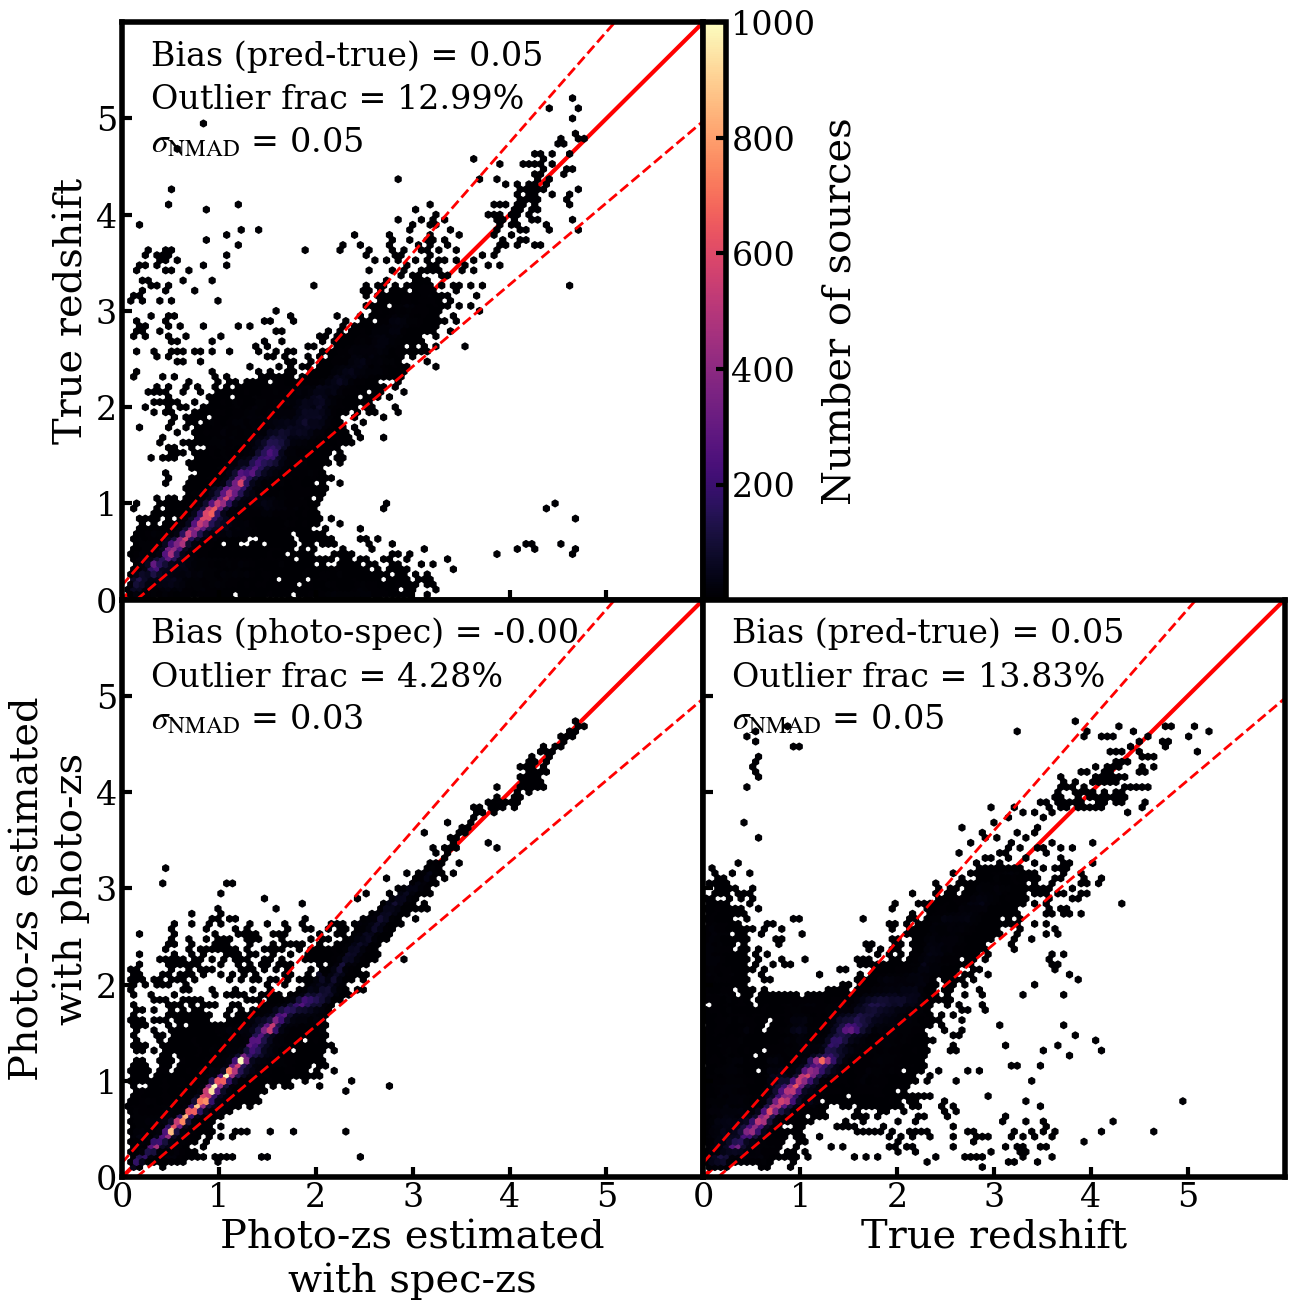

In [47]:
fig = plt.figure(figsize = (15, 15))
axs = fig.subplots(2, 2)

hexbin_props = dict(
    mincnt = 1,
    extent = [0, 6, 0, 6],
    vmin = 1,
    vmax = 1000
)


ax_bl = axs[1, 0]
ax_bl.hexbin(PHOTOZS_estimated_wSpecZs, PHOTOZS_estimated_wPhotoZs, **hexbin_props)
ax_bl.set_xlabel("Photo-zs estimated\nwith spec-zs")
ax_bl.set_ylabel("Photo-zs estimated\nwith photo-zs")
ax_bl.axline((0, 0), slope = 1, color = "red", zorder =0 )
ax_bl.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_bl.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)
ax_bl.set_xlim(hexbin_props["extent"][0], hexbin_props["extent"][1])
ax_bl.set_ylim(hexbin_props["extent"][0], hexbin_props["extent"][1])
ax_bl.set_xticks(np.arange(hexbin_props["extent"][0], hexbin_props["extent"][1], 1))
ax_bl.set_yticks(np.arange(hexbin_props["extent"][0], hexbin_props["extent"][1], 1))
ax_bl.text(0.05, 0.925, rf"Bias (photo-spec) = {prediction_bias(PHOTOZS_estimated_wPhotoZs, PHOTOZS_estimated_wSpecZs):.2f}",
           transform = ax_bl.transAxes)#, backgroundcolor = "white")
ax_bl.text(0.05, 0.85, rf"Outlier frac = {100 * outlier_frac(PHOTOZS_estimated_wPhotoZs, PHOTOZS_estimated_wSpecZs):.2f}%",
           transform = ax_bl.transAxes)#, backgroundcolor = "white")
ax_bl.text(0.05, 0.775, rf"$\sigma_{{\mathrm{{NMAD}}}}$ = {sigma_nmad(PHOTOZS_estimated_wPhotoZs, PHOTOZS_estimated_wSpecZs):.2f}",
           transform = ax_bl.transAxes)#, backgroundcolor = "white")

ax_tl = axs[0, 0]
ax_tl.hexbin(PHOTOZS_estimated_wSpecZs, REDSHIFTS_WideFastDeep, **hexbin_props)
ax_tl.set_ylabel("True redshift")
ax_tl.axline((0, 0), slope = 1, color = "red", zorder = 0)
ax_tl.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_tl.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)
ax_tl.set_xlim(hexbin_props["extent"][0], hexbin_props["extent"][1])
ax_tl.set_ylim(hexbin_props["extent"][0], hexbin_props["extent"][1])
ax_tl.set_xticks(np.arange(hexbin_props["extent"][0], hexbin_props["extent"][1], 1), [])
ax_tl.set_yticks(np.arange(hexbin_props["extent"][0], hexbin_props["extent"][1], 1))
ax_tl.text(0.05, 0.925, rf"Bias (pred-true) = {prediction_bias(PHOTOZS_estimated_wSpecZs, REDSHIFTS_WideFastDeep):.2f}",
           transform = ax_tl.transAxes)#, backgroundcolor = "white")
ax_tl.text(0.05, 0.85, rf"Outlier frac = {100 * outlier_frac(PHOTOZS_estimated_wSpecZs, REDSHIFTS_WideFastDeep):.2f}%",
           transform = ax_tl.transAxes)#, backgroundcolor = "white")
ax_tl.text(0.05, 0.775, rf"$\sigma_{{\mathrm{{NMAD}}}}$ = {sigma_nmad(PHOTOZS_estimated_wSpecZs, REDSHIFTS_WideFastDeep):.2f}",
           transform = ax_tl.transAxes)#, backgroundcolor = "white")

ax_br = axs[1, 1]
ax_br.hexbin(REDSHIFTS_WideFastDeep, PHOTOZS_estimated_wPhotoZs, **hexbin_props)
ax_br.set_xlabel("True redshift")
ax_br.axline((0, 0), slope = 1, color = "red", zorder =0 )
ax_br.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_br.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)
ax_br.set_xlim(hexbin_props["extent"][0], hexbin_props["extent"][1])
ax_br.set_ylim(hexbin_props["extent"][0], hexbin_props["extent"][1])
ax_br.set_xticks(np.arange(hexbin_props["extent"][0], hexbin_props["extent"][1], 1))
ax_br.set_yticks(np.arange(hexbin_props["extent"][0], hexbin_props["extent"][1], 1), [])
ax_br.text(0.05, 0.925, rf"Bias (pred-true) = {prediction_bias(PHOTOZS_estimated_wPhotoZs, REDSHIFTS_WideFastDeep):.2f}",
           transform = ax_br.transAxes)#, backgroundcolor = "white")
ax_br.text(0.05, 0.85, rf"Outlier frac = {100 * outlier_frac(PHOTOZS_estimated_wPhotoZs, REDSHIFTS_WideFastDeep):.2f}%",
           transform = ax_br.transAxes)#, backgroundcolor = "white")
ax_br.text(0.05, 0.775, rf"$\sigma_{{\mathrm{{NMAD}}}}$ = {sigma_nmad(PHOTOZS_estimated_wPhotoZs, REDSHIFTS_WideFastDeep):.2f}",
           transform = ax_br.transAxes)#, backgroundcolor = "white")

# fig.text(0.65, 0.515, f"Number of sources:\nFor training FlexZBoost: {len(PHOTOMETRY_DeepField_noisy):,}\nTo get photo-zs for: {len(PHOTOMETRY_WideFastDeep_noisy):,}",)

mappable = axs[1, 0].hexbin([], [], **hexbin_props)
axs[0, 1].set_aspect(.025)
axs[0, 1].set_anchor("SW")
fig.colorbar(mappable = mappable, cax = axs[0, 1], label = "Number of sources")
fig.subplots_adjust(hspace = 0, wspace = 0)
fig.savefig(f"{outputs_directory}/photoZ_comparison_plot.png", dpi = 150, transparent = True, bbox_inches = "tight")

In [48]:
z_lo = 0; z_hi = 6; z_step = 0.5
ZBINS = np.arange(z_lo, z_hi, z_step)

BIN_IDX_specZs  = np.digitize(PHOTOZS_estimated_wSpecZs, bins = ZBINS)
BIN_IDX_photoZs = np.digitize(PHOTOZS_estimated_wPhotoZs, bins = ZBINS)


outlier_frac_specZs  = outlier_frac(PHOTOZS_estimated_wSpecZs, REDSHIFTS_WideFastDeep)
outlier_frac_photoZs = outlier_frac(PHOTOZS_estimated_wPhotoZs, REDSHIFTS_WideFastDeep)

OUTLIER_FRACS_binned_specZs = np.array([outlier_frac(PHOTOZS_estimated_wSpecZs[BIN_IDX_specZs == i_bin],
                                                     REDSHIFTS_WideFastDeep[BIN_IDX_specZs == i_bin])\
                                                for i_bin in range(1, len(ZBINS) + 1)])

OUTLIER_FRACS_binned_photoZs = np.array([outlier_frac(PHOTOZS_estimated_wPhotoZs[BIN_IDX_photoZs == i_bin],
                                                      REDSHIFTS_WideFastDeep[BIN_IDX_photoZs == i_bin])\
                                                for i_bin in range(1, len(ZBINS) + 1)])


sigma_nmad_specZs  = sigma_nmad(PHOTOZS_estimated_wSpecZs, REDSHIFTS_WideFastDeep)
sigma_nmad_photoZs = sigma_nmad(PHOTOZS_estimated_wPhotoZs, REDSHIFTS_WideFastDeep)

SIGMA_NMADS_binned_specZs = np.array([sigma_nmad(PHOTOZS_estimated_wSpecZs[BIN_IDX_specZs == i_bin],
                                                 REDSHIFTS_WideFastDeep[BIN_IDX_specZs == i_bin])\
                                                for i_bin in range(1, len(ZBINS) + 1)])

SIGMA_NMADS_binned_photoZs = np.array([sigma_nmad(PHOTOZS_estimated_wPhotoZs[BIN_IDX_photoZs == i_bin],
                                                  REDSHIFTS_WideFastDeep[BIN_IDX_photoZs == i_bin])\
                                                for i_bin in range(1, len(ZBINS) + 1)])


prediction_bias_specZs  = prediction_bias(PHOTOZS_estimated_wSpecZs,  REDSHIFTS_WideFastDeep)
prediction_bias_photoZs = prediction_bias(PHOTOZS_estimated_wPhotoZs, REDSHIFTS_WideFastDeep)

PREDICTION_BIASES_binned_specZs = np.array([prediction_bias(PHOTOZS_estimated_wSpecZs[BIN_IDX_specZs == i_bin],
                                                            REDSHIFTS_WideFastDeep[BIN_IDX_specZs == i_bin])\
                                                for i_bin in range(1, len(ZBINS) + 1)])

PREDICTION_BIASES_binned_photoZs = np.array([prediction_bias(PHOTOZS_estimated_wPhotoZs[BIN_IDX_photoZs == i_bin],
                                                             REDSHIFTS_WideFastDeep[BIN_IDX_photoZs == i_bin])\
                                                for i_bin in range(1, len(ZBINS) + 1)])

/tmp/ipykernel_656268/4009573499.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (np.abs(delta_z)/(1 + z_true) > 0.15).sum()/len(delta_z)
/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


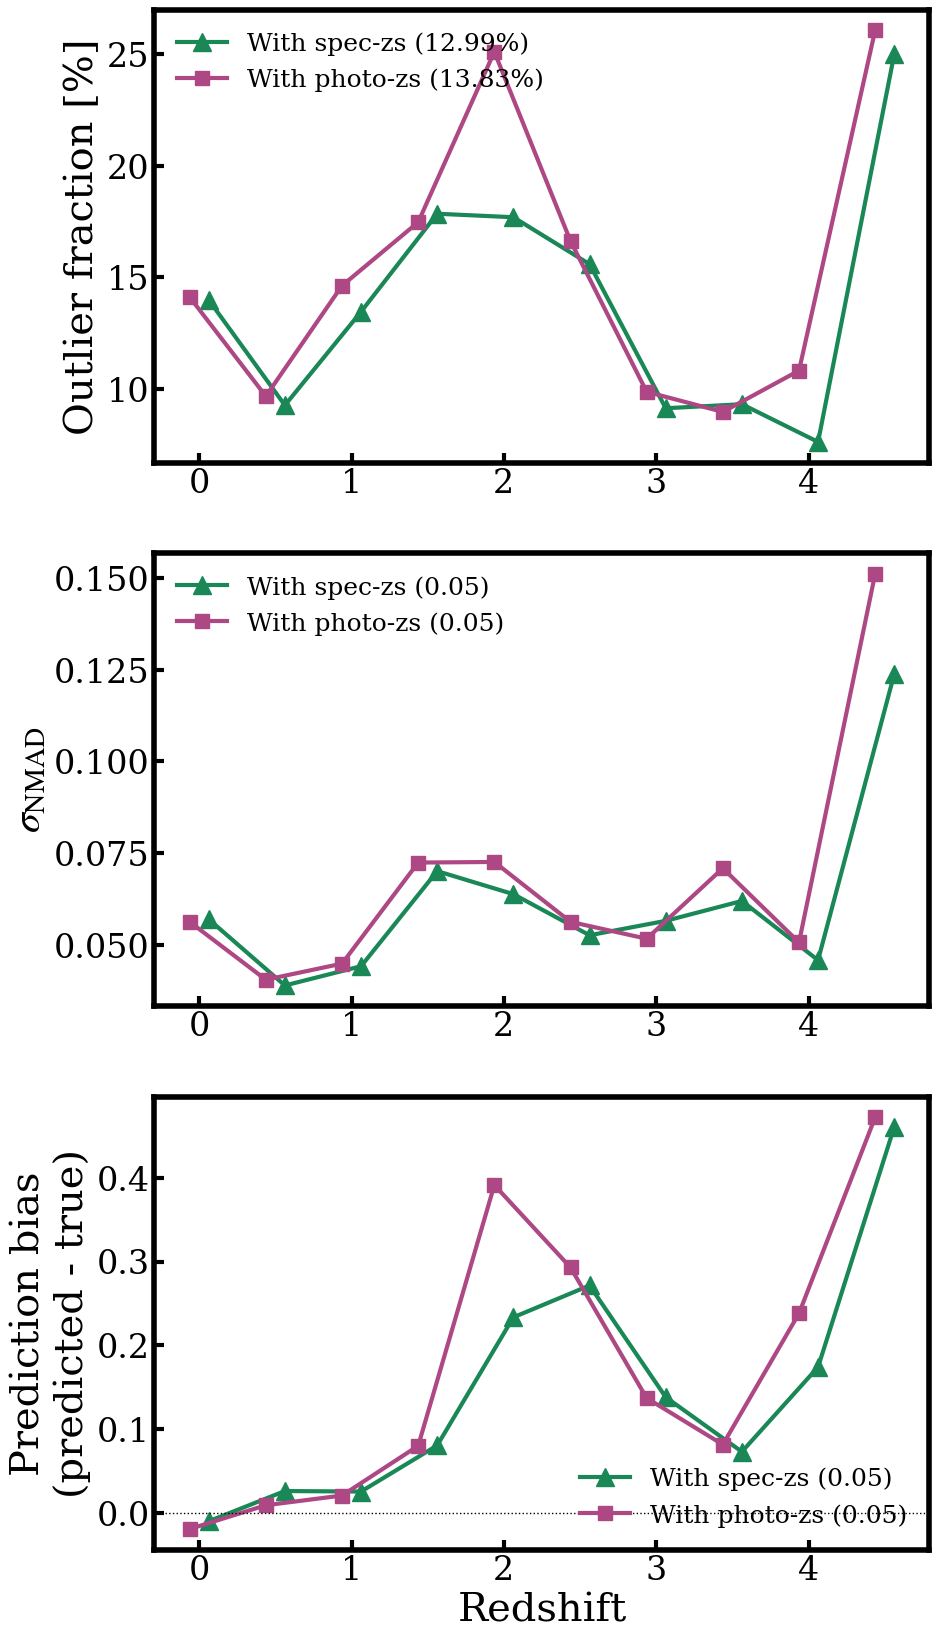

In [49]:
fig = plt.figure(figsize = (10, 20))
axs = fig.subplots(3, 1)

ax_t = axs[0]
ax_t.plot(ZBINS + z_step/8, 100 * OUTLIER_FRACS_binned_specZs,
                   marker = "^", markersize = 12.5, label = f"With spec-zs ({100*outlier_frac_specZs:.2f}%)")
ax_t.plot(ZBINS - z_step/8, 100 * OUTLIER_FRACS_binned_photoZs,
                   marker = 's', markersize = 10, label = f"With photo-zs ({100*outlier_frac_photoZs:.2f}%)")

ax_t.legend(frameon = False, fontsize = 18)
ax_t.set_ylabel("Outlier fraction [%]")


ax_m = axs[1]
ax_m.plot(ZBINS + z_step/8, SIGMA_NMADS_binned_specZs,
                   marker = "^", markersize = 12.5, label = f"With spec-zs ({sigma_nmad_specZs:.2f})")
ax_m.plot(ZBINS - z_step/8, SIGMA_NMADS_binned_photoZs,
                   marker = 's', markersize = 10, label = f"With photo-zs ({sigma_nmad_photoZs:.2f})")

ax_m.legend(frameon = False, fontsize = 18)
ax_m.set_ylabel(r"$\sigma_{\mathrm{NMAD}}$")


ax_b = axs[2]
ax_b.plot(ZBINS + z_step/8, PREDICTION_BIASES_binned_specZs,
                   marker = "^", markersize = 12.5, label = f"With spec-zs ({prediction_bias_specZs:.2f})")
ax_b.plot(ZBINS - z_step/8, PREDICTION_BIASES_binned_photoZs,
                   marker = 's', markersize = 10, label = f"With photo-zs ({prediction_bias_photoZs:.2f})")

ax_b.axhline(0, linestyle = ':', color = "black", linewidth = 1)

ax_b.legend(frameon = False, fontsize = 18)
ax_b.set_ylabel("Prediction bias\n(predicted - true)")
ax_b.set_xlabel("Redshift")

fig.savefig(f"{outputs_directory}/binned_photoZ_comparison_plot.png", dpi = 150, transparent = True, bbox_inches = "tight")